In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Load dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()

# Filter only Cat (3) and Dog (5)
train_filter = (train_labels == 3) | (train_labels == 5)
test_filter  = (test_labels == 3) | (test_labels == 5)

X_train = train_images[train_filter.flatten()]
y_train = train_labels[train_filter.flatten()]
X_test  = test_images[test_filter.flatten()]
y_test  = test_labels[test_filter.flatten()]

# Convert labels: Cat=0, Dog=1
y_train = (y_train == 5).astype(int)
y_test  = (y_test == 5).astype(int)

# Normalize images
X_train = X_train / 255.0
X_test  = X_test / 255.0

# 2. CNN Architecture
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')   # Binary output
])

# 3. Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 4. Train model
model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

# 5. Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 223s 1us/step
Epoch 1/10


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5223 - loss: 0.6914 - val_accuracy: 0.6070 - val_loss: 0.6608
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6314 - loss: 0.6424 - val_accuracy: 0.6970 - val_loss: 0.5783
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7091 - loss: 0.5672 - val_accuracy: 0.7290 - val_loss: 0.5410
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7492 - loss: 0.5145 - val_accuracy: 0.7550 - val_loss: 0.5130
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7684 - loss: 0.4805 - val_accuracy: 0.7560 - val_loss: 0.4891
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7924 - loss: 0.4473 - val_accuracy: 0.7400 - val_loss: 0.5069
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8133 - loss: 0.4025 - val_accuracy: 0.7630 - val_loss: 0.5025
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8410 - loss: 0.3634 - val_accuracy: 0.776

In [2]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [5]:
import matplotlib.pyplot as plt

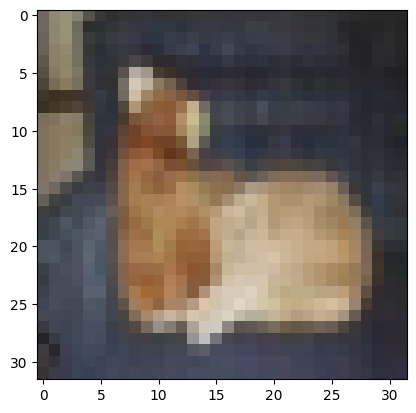

In [9]:
plt.imshow(X_train[1])



In [10]:
print(y_train[1])


[0]
